In [ ]:
# Unzip the augmented dataset (No_signature, Mr_Ting, Russell, Brandon_Wee class)
import zipfile
import os
with zipfile.ZipFile('/content/Cropped_Signatures.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [ ]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 30
NUM_CLASSES = 4

In [3]:
# Load Data

train_dataset = tf.keras.utils.image_dataset_from_directory(
    'dataset',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    'dataset',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
)
class_names = train_dataset.class_names
print("Classes detected:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)


Found 200 files belonging to 4 classes.
Using 160 files for training.
Found 200 files belonging to 4 classes.
Using 40 files for validation.
Classes detected: ['Brandon_Wee', 'Mr_Ting', 'No_Signature', 'Russell']


In [ ]:
# Data Augmentation
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
    layers.RandomZoom(0.05),
])

#  Build the Model
def build_signature_model(img_size, num_classes):
    inputs = layers.Input(shape=img_size + (3,))

    # Dynamic Augmentation 
    data_augmentation = models.Sequential([
        layers.RandomRotation(0.05),
        layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
        layers.RandomZoom(0.05),
    ])

    x = data_augmentation(inputs)
    x = preprocess_input(x)

    base_model = MobileNetV2(input_shape=img_size + (3,), include_top=False, weights='imagenet')
    base_model.trainable = False  # Freeze base weights

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

model = build_signature_model(IMG_SIZE, NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
# Applying early Stopping
training_callbacks = [
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

Starting training...
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.4250 - loss: 1.3419 - val_accuracy: 0.3250 - val_loss: 1.4599 - learning_rate: 0.0010
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5562 - loss: 1.0414 - val_accuracy: 0.5000 - val_loss: 1.0739 - learning_rate: 0.0010
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6562 - loss: 0.9048 - val_accuracy: 0.6250 - val_loss: 0.9223 - learning_rate: 0.0010
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7250 - loss: 0.7763 - val_accuracy: 0.7000 - val_loss: 0.7795 - learning_rate: 0.0010
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8062 - loss: 0.5857 - val_accuracy: 0.6750 - val_loss: 0.7466 - learning_rate: 0.0010
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8438 - loss: 0.5147 - val_accuracy: 0.7750 - val_loss: 0.6313 - learning_rate: 0.0010
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8125 -

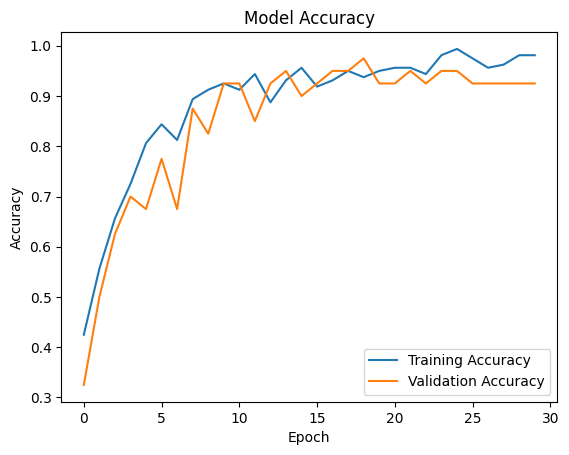

In [ ]:
# Train the Model
print("Starting training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=training_callbacks
)

# Plot Results
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



--- Evaluating Model on Validation Set ---

Classification Report:
              precision    recall  f1-score   support

 Brandon_Wee       1.00      1.00      1.00         6
     Mr_Ting       1.00      0.86      0.92        14
No_Signature       1.00      1.00      1.00        11
     Russell       0.82      1.00      0.90         9

    accuracy                           0.95        40
   macro avg       0.95      0.96      0.96        40
weighted avg       0.96      0.95      0.95        40



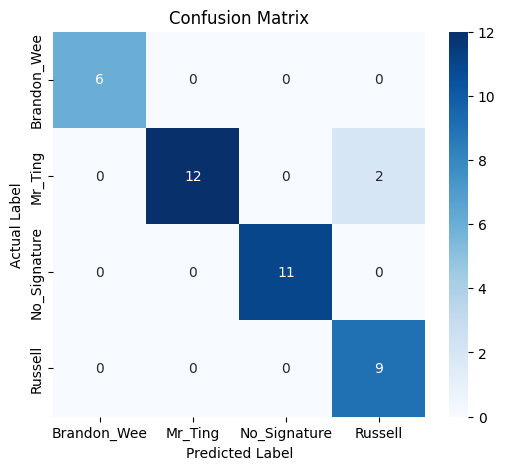

In [7]:
# Evaluation Metrics
print("\n--- Evaluating Model on Validation Set ---")
y_true = []
y_pred = []
for x, y in val_dataset:
    y_true.extend(np.argmax(y.numpy(), axis=1))
    batch_preds = model.predict(x, verbose=0)
    y_pred.extend(np.argmax(batch_preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


In [8]:
# Export the Model
model.save('signature_classifier.keras')
print("\nModel successfully saved as signature_classifier.h5!")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('signature_classifier.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model successfully saved as signature_classifier.tflite!")


Model successfully saved as signature_classifier.h5!
Saved artifact at '/tmp/tmp908g6dmp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135367440430096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135367438840272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135367438840080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135367438840464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135367438838160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135367438841040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135367438841424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135367438841232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135367438840848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135367438841616: TensorSpec(sh